In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import gudhi.point_cloud.timedelay as td
from tqdm.auto import tqdm
import seaborn as sns
import gudhi.representations as gr
import utils_dtm
import pandas as pd
from copy import deepcopy
import scipy
import scipy.integrate

import yfinance as yf

import persistence_statistics as ps

import tsi_functions as tsi
import tsi_functions.time_series as tsi_ts

# Brownian motion

In [ ]:
# def brownian_motion(mu, sigma, dt):
#     # m = (mu - 0.5 * sigma**2)
#     # s = sigma
#     logret = np.random.normal(mu, sigma * np.sqrt(dt), size=int(1/dt))
#     price = logret.cumsum()
#     return price

# def geometric_brownian_motion(mu, sigma, dt, n_steps=None):
#     if n_steps is None:
#         n_steps = int(1/dt)
#     m = (mu - 0.5 * sigma**2)
#     s = sigma
#     logret = np.random.normal(m * dt, s * np.sqrt(dt), size=n_steps)
#     price = np.exp(logret.cumsum())
#     return price

## Examples

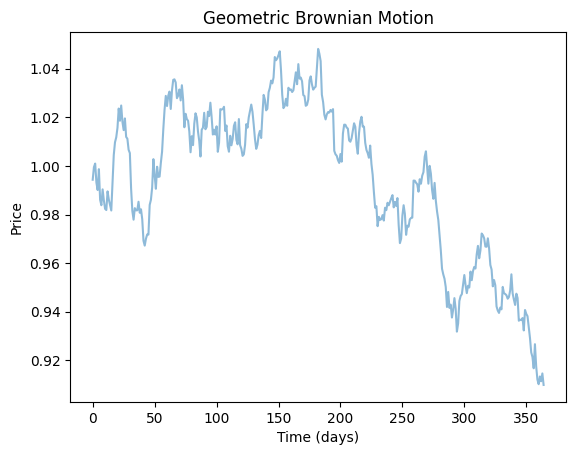

In [2]:
np.random.seed(123)

for i in range(1):
    price = tsi_ts.geometric_brownian_motion(mu=0, sigma=0.1, dt=1/365)

    plt.plot(price, alpha=0.5)
plt.title("Geometric Brownian Motion")
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.show()

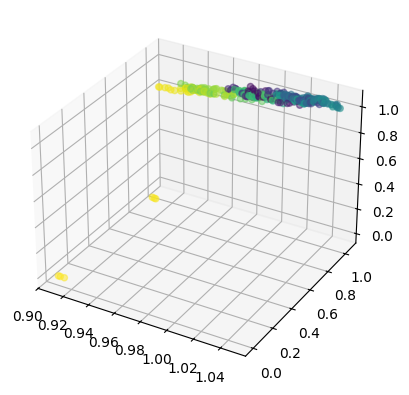

In [5]:
points = td.TimeDelayEmbedding(dim=3, delay=3, skip=1)(np.append(price, np.zeros(6)))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], alpha=0.5, c=np.linspace(0, 1, len(points)), marker="o")
plt.show()

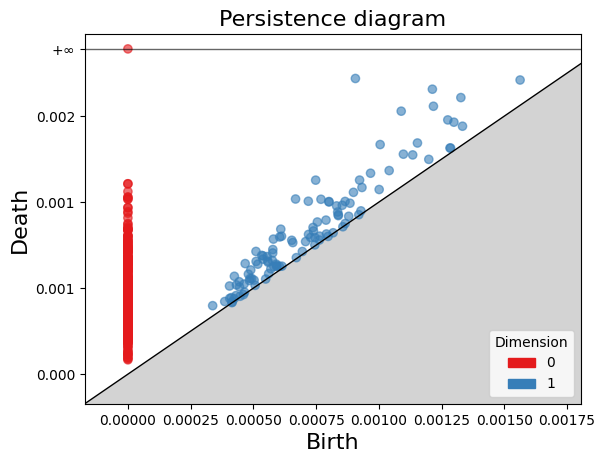

In [ ]:
persistence = tsi_ts.persistence_timedelay(price, dim=3, delay=3, skip=1, filtration_type="rips")
bars = [bar for _, bar in persistence]
gd.plot_persistence_diagram(persistence)
plt.show()

## Describing whole sequence

In [2]:
def simulate_and_compute_TSI(mu, sigma, dt, dim, delay, skip, n, dtm=False, dtm_m=0.03, seed=None, n_steps=None, remove_inf_fun = tsi.remove_inf(), summary_functions = tsi_ts.bm_summary_functions, filt_method = "timedelay", filtration_type = "rips"):
    """
    methods: dict of method name to tuple (use_persistence: Bool, function)
    """
    if seed is not None:
        np.random.seed(seed)
    out_dict = {
        method: [] for method in summary_functions.function_names
    }
    for i in tqdm(range(n), leave = False):
        price = tsi_ts.geometric_brownian_motion(mu, sigma, dt, n_steps)
        if filt_method == "timedelay":
            persistence = tsi_ts.persistence_timedelay(price, dim, delay, skip, filtration_type = filtration_type, dtm=dtm, dtm_m=dtm_m)
        elif filt_method == "timesublevel":
            persistence = tsi_ts.persistence_timesublevel(price, max_dimension=0)
        func_evals = summary_functions(persistence, price=price, dt=dt)
        for method_name, value in func_evals.items():
            out_dict[method_name].append(value)
    return out_dict

def plot_simulation_results(simulation_results, params_per_method = None):
    swapped_results = {}
    for param, results in simulation_results.items():
        for method in results.keys():
            if method not in swapped_results:
                swapped_results[method] = {}
            if params_per_method is not None and method.split('-')[0] in params_per_method:
                if param not in params_per_method[method.split('-')[0]]:
                    continue
            swapped_results[method][param] = results[method]
    
    fig, ax = plt.subplots(nrows = int(np.ceil(len(swapped_results)/4)), ncols=min(4, len(swapped_results)), figsize=(5*min(4, len(swapped_results)), 5*(len(swapped_results)//4 + 1)))
    ax = ax.flatten()
    for i, (method, results) in enumerate(swapped_results.items()):
        sns.histplot(data=results, bins=100, ax=ax[i], kde=True, stat="density", element ="step")
        ax[i].set_title(method)
    plt.tight_layout()
    plt.show()

In [ ]:
dtm = False

n=100
n_steps = None
sigma_list = np.linspace(0.005, 0.2, 41)
remove_inf_fun = tsi.remove_inf(type_="mu", lambda_=1)

np.random.seed(123)

gbm_summary_functions = tsi.summary_functions(persistence_functions = {
    "persistent_entropy": lambda bars, lengths: gr.vector_methods.Entropy()(np.array(bars))[0],
    # "normalized_persistent_entropy": lambda bars, lengths: gr.vector_methods.Entropy()(np.array(bars))[0]/np.log(np.sum(lengths)),
    "TSI": lambda bars, lengths: np.var(lengths, ddof=1),
    "logTSI": lambda bars, lengths: np.log(np.var(lengths, ddof=1)),
    # "nTSI": lambda bars, lengths: np.var(lengths, ddof=0) / np.sum(lengths),
    # "mTSI": lambda bars, lengths: np.var(lengths, ddof=0) / np.mean(lengths),
    "cvTSI": lambda bars, lengths: np.var(lengths, ddof=1) / (np.mean(lengths))**2,
    # "stdTSI": lambda bars, lengths: np.std(lengths, ddof=0),
    # "test": lambda bars, lengths: len(lengths)/(len(lengths)-1)*(np.sum([len(lengths)*(lengths[i]/np.sum(lengths))**2 for i in range(len(lengths))])-1),
    # "mean_length": lambda bars, lengths: np.mean(lengths),
    # "sum_length": lambda bars, lengths: np.sum(lengths),
    # "n_bars": lambda bars, lengths: len(bars),
    "TSigI": lambda bars, lengths: np.sum(lengths**2) / np.sum(lengths) if np.sum(lengths) > 0 else 0,
    "normalized_cvTSI": lambda bars, lengths: np.var(lengths, ddof=1) / (np.mean(lengths))**2 / len(bars) if np.sum(lengths) > 0 and len(lengths) > 1 else 0,
}, remove_inf_fun=tsi.remove_inf(type_="mu", lambda_= 1),
dims=[0, 1]
)

# tsi_ts.bm_summary_functions.set_dims([0, 1, "all", "sum"])
tsi_ts.bm_summary_functions.set_dims([0, 1])
# bm_summary_functions.set_dims(["all"])

simulation_results_different_sigma = {}
for sigma in tqdm(sigma_list):
    simulation_results_different_sigma[sigma] = \
    simulate_and_compute_TSI(mu=0, sigma=sigma, dt=1/365, dim=3, delay=3, skip=1, 
                             n=n, seed=123, n_steps=n_steps, dtm=dtm, dtm_m=0.03, remove_inf_fun=remove_inf_fun, summary_functions=gbm_summary_functions,
                             filt_method="timedelay", filtration_type="alpha")


Text(0.5, 1.0, 'Summary functions for geometric Brownian motion with different volatility')

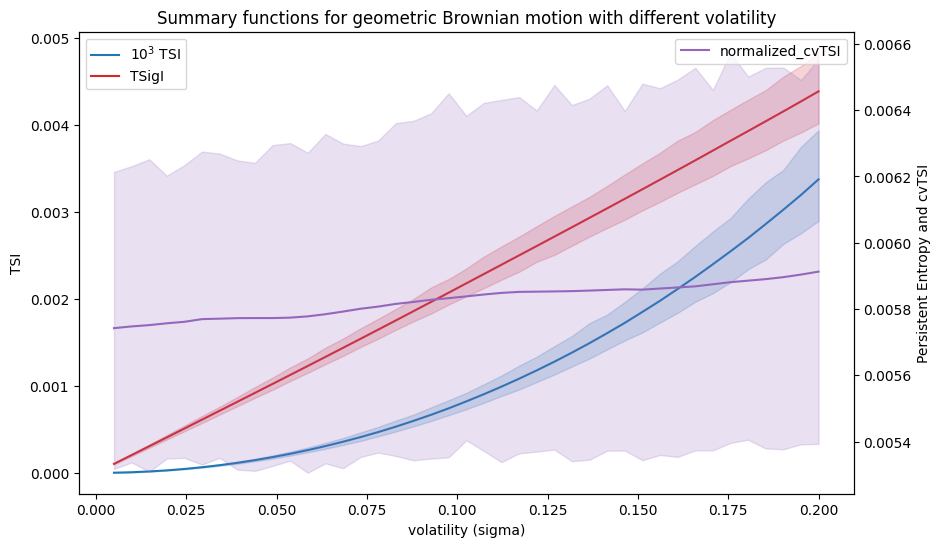

In [21]:
fig, ax_left = plt.subplots(figsize=(10, 6))

ax_right = ax_left.twinx()

sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_sigma[sigma]["TSI-1"])*1000 for sigma in sigma_list]), x=np.repeat(sigma_list, n), label="$10^3$ TSI", errorbar=("ci", 95), color="tab:blue", ax=ax_left)
# sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_sigma[sigma]["persistent_entropy-1"]) for sigma in sigma_list]), x=np.repeat(sigma_list, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax_right)
# sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_sigma[sigma]["cvTSI-1"]) for sigma in sigma_list]), x=np.repeat(sigma_list, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_sigma[sigma]["TSigI-1"]) for sigma in sigma_list]), x=np.repeat(sigma_list, n), label="TSigI", errorbar=("ci", 95), color="tab:red", ax=ax_left)
sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_sigma[sigma]["normalized_cvTSI-1"]) for sigma in sigma_list]), x=np.repeat(sigma_list, n), label="normalized_cvTSI", errorbar=("ci", 95), color="tab:purple", ax=ax_right)

ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")
ax_left.set_ylabel("TSI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")


# plt.xlabel("Num")
ax_left.set_xlabel("volatility (sigma)")
# plt.ylabel("Summary function value")
plt.title("Summary functions for geometric Brownian motion with different volatility")

In [ ]:
dtm = False

n=100
n_steps = None
mu_list = np.linspace(-0.2, 0.2, 41)
sigma = 0.1
remove_inf_fun = tsi.remove_inf(type_="mu", lambda_=1)

np.random.seed(123)

# gbm_summary_functions = tsi.summary_functions(persistence_functions = {
#     "persistent_entropy": lambda bars, lengths: gr.vector_methods.Entropy()(np.array(bars))[0],
#     # "normalized_persistent_entropy": lambda bars, lengths: gr.vector_methods.Entropy()(np.array(bars))[0]/np.log(np.sum(lengths)),
#     "TSI": lambda bars, lengths: np.var(lengths, ddof=1),
#     "logTSI": lambda bars, lengths: np.log(np.var(lengths, ddof=1)),
#     # "nTSI": lambda bars, lengths: np.var(lengths, ddof=0) / np.sum(lengths),
#     # "mTSI": lambda bars, lengths: np.var(lengths, ddof=0) / np.mean(lengths),
#     "cvTSI": lambda bars, lengths: np.var(lengths, ddof=1) / (np.mean(lengths))**2,
#     # "stdTSI": lambda bars, lengths: np.std(lengths, ddof=0),
#     # "test": lambda bars, lengths: len(lengths)/(len(lengths)-1)*(np.sum([len(lengths)*(lengths[i]/np.sum(lengths))**2 for i in range(len(lengths))])-1),
#     # "mean_length": lambda bars, lengths: np.mean(lengths),
#     # "sum_length": lambda bars, lengths: np.sum(lengths),
#     # "n_bars": lambda bars, lengths: len(bars)
# }, remove_inf_fun=tsi.remove_inf(type_="mu", lambda_= 1),
# dims=[0, 1]
# )

# tsi_ts.bm_summary_functions.set_dims([0, 1, "all", "sum"])
tsi_ts.bm_summary_functions.set_dims([0, 1])
# bm_summary_functions.set_dims(["all"])

simulation_results_different_mu = {}
for mu in tqdm(mu_list):
    simulation_results_different_mu[mu] = \
    simulate_and_compute_TSI(mu=mu, sigma=sigma, dt=1/365, dim=3, delay=3, skip=1, 
                             n=n, seed=123, n_steps=n_steps, dtm=dtm, dtm_m=0.03, remove_inf_fun=remove_inf_fun, summary_functions=gbm_summary_functions,
                             filt_method="timedelay", filtration_type="alpha")


Text(0.5, 1.0, 'Summary functions for geometric Brownian motion with different drift')

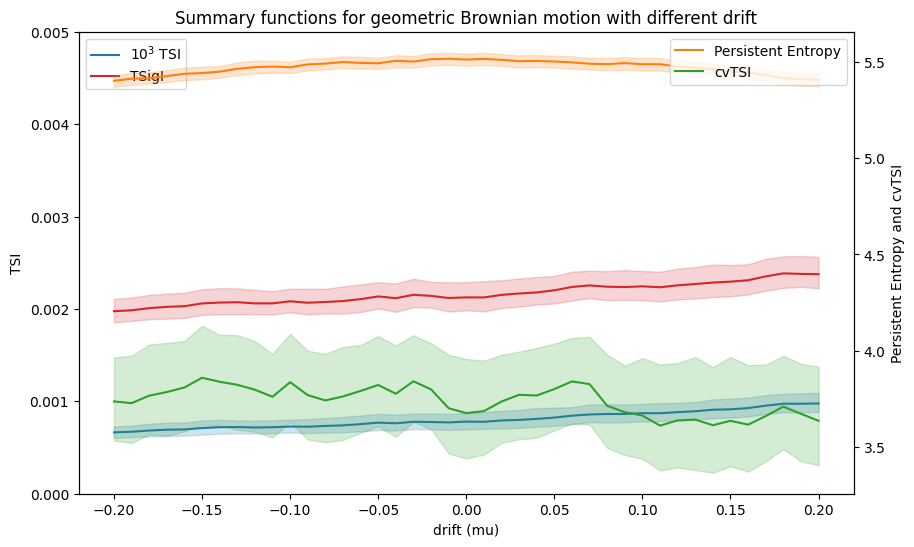

In [18]:
fig, ax_left = plt.subplots(figsize=(10, 6))

ax_right = ax_left.twinx()

sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_mu[mu]["TSI-1"])*1000 for mu in mu_list]), x=np.repeat(mu_list, n), label="$10^3$ TSI", errorbar=("ci", 95), color="tab:blue", ax=ax_left)
sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_mu[mu]["persistent_entropy-1"]) for mu in mu_list]), x=np.repeat(mu_list, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_mu[mu]["cvTSI-1"]) for mu in mu_list]), x=np.repeat(mu_list, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_mu[mu]["TSigI-1"]) for mu in mu_list]), x=np.repeat(mu_list, n), label="TSigI", errorbar=("ci", 95), color="tab:red", ax=ax_left)
# sns.lineplot(y=np.concatenate([np.nan_to_num(simulation_results_different_mu[mu]["normalized_cvTSI-1"]) for mu in mu_list]), x=np.repeat(mu_list, n), label="normalized_cvTSI", errorbar=("ci", 95), color="tab:purple", ax=ax_right)

ax_left.legend(loc="upper left")
ax_left.set_ylim(bottom=0, top=5e-3)
ax_right.legend(loc="upper right")
ax_left.set_ylabel("TSI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")


# plt.xlabel("Num")
ax_left.set_xlabel("drift (mu)")
# plt.ylabel("Summary function value")
plt.title("Summary functions for geometric Brownian motion with different drift")